In [1]:
# basic libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# preprocessing
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# model + tuning
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV

# evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# multicollinearity check
from statsmodels.stats.outliers_influence import variance_inflation_factor


In [2]:
# Load the training and testing datasets
train = pd.read_csv("train_df.csv")
test  = pd.read_csv("test_df.csv")

In [3]:
# Target column name
target = "salary_in_usd"

In [4]:
# Split into features (X) and labels (y)
X_train = train.drop(columns=[target])
y_train = train[target]

X_test = test.drop(columns=[target])
y_test = test[target]

Initial VIF check (including employee_residence & company_location)

In [5]:
# define high-cardinality columns to frequency-encode for VIF
freq_cols = ["job_title", "employee_residence", "company_location"]
numeric_base = ["work_year", "remote_ratio"]

In [6]:
# Frequency-encode high-cardinality columns (using train frequencies)
X_vif = X_train.copy()
for c in freq_cols:
    freq = X_vif[c].value_counts() / len(X_vif)
    X_vif[c] = X_vif[c].map(freq).fillna(0.0)

# Build numeric-only frame for VIF
numeric_for_vif = X_vif[numeric_base + freq_cols].apply(pd.to_numeric, errors="coerce")
numeric_for_vif = numeric_for_vif.replace([np.inf, -np.inf], np.nan).fillna(0.0)

# Compute VIF
vif_list = []
for i in range(numeric_for_vif.shape[1]):
    try:
        v = variance_inflation_factor(numeric_for_vif.values, i)
    except Exception:
        v = np.nan
    vif_list.append(v)

vif_table = pd.DataFrame({"feature": numeric_for_vif.columns, "VIF": vif_list}).sort_values("VIF", ascending=False)
print("\nVIF (numeric + freq-encoded columns)-1:")
print(vif_table)




VIF (numeric + freq-encoded columns)-1:
              feature         VIF
4    company_location  650.708836
3  employee_residence  646.067003
0           work_year    9.034824
2           job_title    2.503568
1        remote_ratio    1.337868


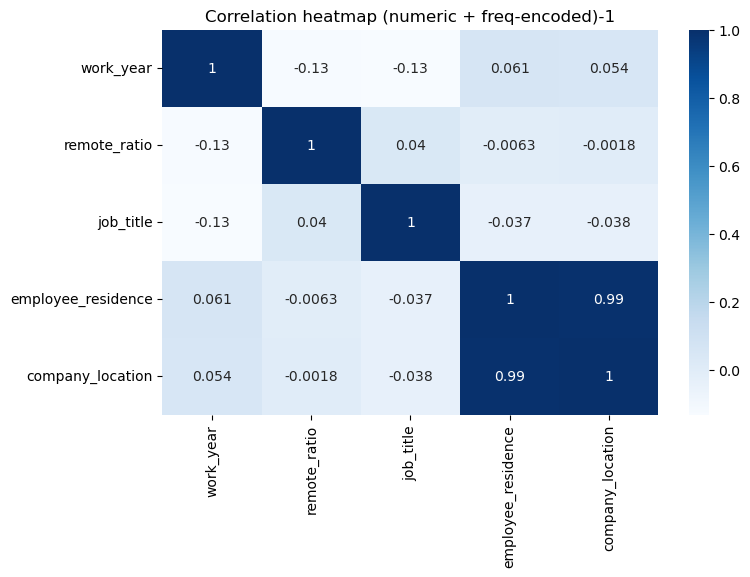

In [7]:
# Correlation heatmap
plt.figure(figsize=(8,5))
sns.heatmap(numeric_for_vif.corr(), annot=True, cmap="Blues")
plt.title("Correlation heatmap (numeric + freq-encoded)-1")
plt.show()

Drop highly collinear column

In [8]:
# # remove employee_residence because it is nearly collinear with company_location
X_train = X_train.drop(columns=["employee_residence"])
X_test = X_test.drop(columns=["employee_residence"])

In [9]:
# update freq and numeric lists accordingly
freq_cols = ["job_title", "company_location"]   # employee_residence removed
numeric_base = ["work_year", "remote_ratio"]


In [10]:
# Frequency-encode high-cardinality columns (using train frequencies)
X_vif = X_train.copy()
for c in freq_cols:
    freq = X_vif[c].value_counts() / len(X_vif)
    X_vif[c] = X_vif[c].map(freq).fillna(0.0)

# Build numeric-only frame for VIF
numeric_for_vif = X_vif[numeric_base + freq_cols].apply(pd.to_numeric, errors="coerce")
numeric_for_vif = numeric_for_vif.replace([np.inf, -np.inf], np.nan).fillna(0.0)

# Compute VIF
vif_list = []
for i in range(numeric_for_vif.shape[1]):
    try:
        v = variance_inflation_factor(numeric_for_vif.values, i)
    except Exception:
        v = np.nan
    vif_list.append(v)

vif_table = pd.DataFrame({"feature": numeric_for_vif.columns, "VIF": vif_list}).sort_values("VIF", ascending=False)
print("\nVIF (numeric + freq-encoded columns)-2:")
print(vif_table)


VIF (numeric + freq-encoded columns)-2:
            feature       VIF
0         work_year  9.033308
3  company_location  7.029763
2         job_title  2.503124
1      remote_ratio  1.335242


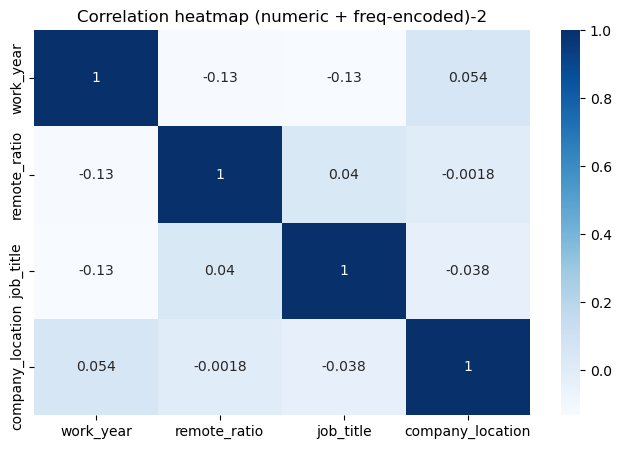

In [11]:
# Correlation heatmap
plt.figure(figsize=(8,5))
sns.heatmap(numeric_for_vif.corr(), annot=True, cmap="Blues")
plt.title("Correlation heatmap (numeric + freq-encoded)-2")
plt.show()

Frequency Encoding

In [12]:
#Frequency-encode train/test for pipeline use
def freq_encode_train_test(train_df, test_df, cols):
    train_df = train_df.copy()
    test_df = test_df.copy()
    for c in cols:
        freq = train_df[c].value_counts() / len(train_df)
        train_df[c] = train_df[c].map(freq).fillna(0.0)
        test_df[c] = test_df[c].map(freq).fillna(0.0)
    return train_df, test_df

In [13]:
# apply frequency encoding to train/test (for modeling)
X_train_freq, X_test_freq = freq_encode_train_test(X_train, X_test, freq_cols)

Preprocessing Pipeline

In [14]:
# small categorical columns to one-hot encode
onehot_cols = ["experience_level", "employment_type", "company_size"]

# numeric columns include numeric_base + freq columns
numeric_cols = ["work_year", "remote_ratio"] + freq_cols

In [15]:
# ColumnTransformer: one-hot small cats + scale numeric columns
preprocessor = ColumnTransformer(
    transformers=[
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False), onehot_cols),
        ("scale", StandardScaler(), numeric_cols)
    ],
    remainder="drop"
)

Build Pipeline with KNN

In [16]:
#KNN pipeline
pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("knn", KNeighborsRegressor())
])


Hyperparameter Tuning

In [17]:
# grid for k, weights and metric
param_grid = {
    "knn__n_neighbors":  [3, 5, 7, 9, 11, 15],  
    "knn__weights": ["uniform", "distance"],
    "knn__metric": ["euclidean", "manhattan"]
}

grid = GridSearchCV(
   estimator= pipeline,  
   param_grid=param_grid, 
   cv=5, 
   scoring="neg_mean_squared_error", 
   n_jobs=-1, 
   verbose=1
)


In [18]:
print("\nRunning GridSearchCV...")
# fit on original X_train but using the freq-encoded copies ensures same freq values are used
grid.fit(X_train_freq, y_train)


Running GridSearchCV...
Fitting 5 folds for each of 24 candidates, totalling 120 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocess',
                                        ColumnTransformer(transformers=[('onehot',
                                                                         OneHotEncoder(handle_unknown='ignore',
                                                                                       sparse_output=False),
                                                                         ['experience_level',
                                                                          'employment_type',
                                                                          'company_size']),
                                                                        ('scale',
                                                                         StandardScaler(),
                                                                         ['work_year',
                                                                          'remote_ratio',
                                                                          'job_title',
                                                                          'company_location'])])),
                                       ('knn', KNeighborsRegressor())]),
             n_jobs=-1,
             param_grid={'knn__metric': ['euclidean', 'manhattan'],
                         'knn__n_neighbors': [3, 5, 7, 9, 11, 15],
                         'knn__weights': ['uniform', 'distance']},
             scoring='neg_mean_squared_error', verbose=1)

 Best Model

In [19]:
print("Best Parameters:", grid.best_params_)
print("Best MAE:", -grid.best_score_)

Best Parameters: {'knn__metric': 'manhattan', 'knn__n_neighbors': 15, 'knn__weights': 'uniform'}
Best MAE: 4700848762.898993


 Predictions + Evaluation

In [20]:
# Evaluate on test set
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test_freq)

In [21]:
# compute evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nTest performance (best KNN):")
print(f"MAE  : {mae:.3f}")
print(f"MSE  : {mse:.3f}")
print(f"RMSE : {rmse:.3f}")
print(f"R2   : {r2:.3f}")


Test performance (best KNN):
MAE  : 49595.429
MSE  : 4659055548.784
RMSE : 68257.275
R2   : 0.238


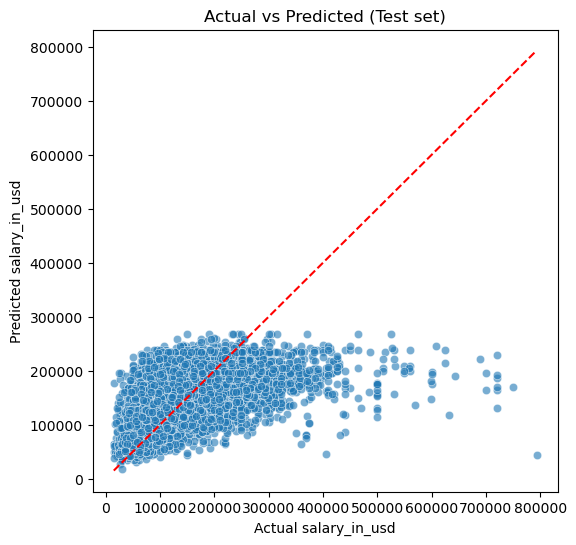

In [22]:
# actual vs predicted plot
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
mn, mx = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
plt.plot([mn, mx], [mn, mx], "--", color="red")
plt.xlabel("Actual salary_in_usd")
plt.ylabel("Predicted salary_in_usd")
plt.title("Actual vs Predicted (Test set)")
plt.show()